In [ ]:
import OptimusPrimus

from OptimusPrimus import OptimusPrimus

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
IMAGE_SPEC = "ARCI URAS26F2"
SEG_MODEL_SPEC = "Best_model_MAnet_efficientnet7_reducelr_dice_dice_bce_th0.1" 
CLASS_MODEL_SPEC = "efficientnetb0_track_model_prec078_rec075"

# Optional configuration dictionaries (only specified parameters override the default values).

IMAGE_CONFIG = {}
SEG_MODEL_CONFIG = {}
CLASS_MODEL_CONFIG = {}

In [ ]:
training_run = False

if training_run:

    TRAIN_IMAGE = {}

    from OptimusPrimus import OptimusPrimusTraining

    train_track_detector = OptimusPrimusTraining(
        train_image=TRAIN_IMAGE, 
        train_model_config=TRAIN_MODEL_CONFIG, 
        training_parameters=TRAINING_PARAMETERS, 
        image_config=IMAGE_CONFIG
    )

    train_track_detector.perform_seg_training()

    # Replace the hardcoded path with the standard SEG_MODEL_SPEC variable
    train_track_detector.perform_class_training(SEG_MODEL_SPEC, seg_th = 0.1)

    # Replace the path arguments with the standard SPEC arguments
    dict_seg_efficiency = train_track_detector.evaluate_binned_efficiency(
        'seg', 
        seg_model_spec=SEG_MODEL_SPEC, 
        cls_model_spec=CLASS_MODEL_SPEC, 
        seg_th = 0.1, 
        cls_th = 0.55
    )
    
    dict_seg_class_efficiency = train_track_detector.evaluate_binned_efficiency(
        'seg_class', 
        seg_model_spec=SEG_MODEL_SPEC, 
        cls_model_spec=CLASS_MODEL_SPEC, 
        seg_th = 0.1, 
        cls_th = 0.55
    )

    print(dict_seg_efficiency['efficiency_table'])

In [ ]:
track_detector = OptimusPrimus(IMAGE_SPEC, SEG_MODEL_SPEC, CLASS_MODEL_SPEC, image_config = IMAGE_CONFIG, seg_model_config = SEG_MODEL_CONFIG, class_model_config = CLASS_MODEL_CONFIG)

Configuration Loaded:
  Image Folder: Data/test-data/ARCI URAS26F2/tiles
  Segmentation Model Path: Data/models/segmentation/Best_model_MAnet_efficientnet7_reducelr_dice_dice_bce_th0.1.pth
  Classification Model Path: Data/models/classification/efficientnetb0_track_model_prec078_rec075.pth
  Segmentation Output Directory: Data/inference_results/segmentation/
  Segmentation and Classification Output Directory: Data/inference_results/seg_class/
  Using Device: cpu


In [ ]:
track_detector.perform_full_inference(seg_th = 0.1, cls_th = 0.55)

File Data/inference_results/seg_class/ARCI URAS26F2_Best_model_MAnet_efficientnet7_reducelr_dice_dice_bce_th0.1_efficientnetb0_track_model_prec078_rec075.csv loaded correctly now if is needed the track lenght distribution plot use : get_track_distribution('seg_class'). 

[OPTIMUS-PRIMUS | DISTRIBUTION ANALYSIS] MODE = seg_class
[STEP 1] Loading ellipse dataset...
[STEP 2] Dataset loaded: 1937 tracks found
[STEP 3] Computing dataset area and density...
[INFO] Total area: 0.392 cm²
[INFO] Track density: 4942.673 cm⁻²
[STEP 4] Writing summary report...
[STEP 5] Computing statistics on 'len_um'...
[INFO] Mean = 4.375, Std = 1.346
[INFO] Median = 4.260
[STEP 6] Generating histograms...
[OUTPUT] Linear plot saved → Data/Distribution/Linear/seg_class/ARCI URAS26F2_Best_model_MAnet_efficientnet7_reducelr_dice_dice_bce_th0.1_efficientnetb0_track_model_prec078_rec075.pdf
[OUTPUT] Log plot saved → Data/Distribution/Log/seg_class/ARCI URAS26F2_Best_model_MAnet_efficientnet7_reducelr_dice_dice_bce_

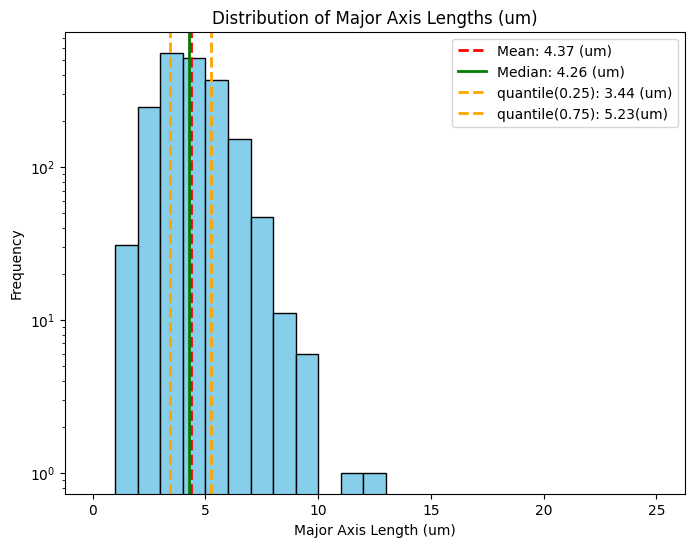

[DONE] Distribution analysis completed



{'track_density_per_cm2': 4942.6728872698595,
 'mean': np.float64(4.374894166236447),
 'std': np.float64(1.34629918268933),
 'low': 3.44,
 'median': 4.26,
 'high': 5.23}

In [5]:
# Load previously saved inference results if needed
track_detector.inference_from_file( "Data/inference_results/seg_class/ARCI URAS26F2_Best_model_MAnet_efficientnet7_reducelr_dice_dice_bce_th0.1_efficientnetb0_track_model_prec078_rec075.csv" )

track_detector.get_track_distributions('seg_class')

File Data/inference_results/segmentation/ARCI URAS26F2_Best_model_MAnet_efficientnet7_reducelr_dice_dice_bce_th0.1.csv loaded correctly now if is needed the track lenght distribution plot use : get_track_distribution('seg'). 

[OPTIMUS-PRIMUS | DISTRIBUTION ANALYSIS] MODE = seg
[STEP 1] Loading ellipse dataset...
[STEP 2] Dataset loaded: 2570 tracks found
[STEP 3] Computing dataset area and density...
[INFO] Total area: 0.403 cm²
[INFO] Track density: 6375.181 cm⁻²
[STEP 4] Writing summary report...
[STEP 5] Computing statistics on 'len_um'...
[INFO] Mean = 4.331, Std = 1.433
[INFO] Median = 4.180
[STEP 6] Generating histograms...
[OUTPUT] Linear plot saved → Data/Distribution/Linear/segmentation/ARCI URAS26F2_Best_model_MAnet_efficientnet7_reducelr_dice_dice_bce_th0.1.pdf
[OUTPUT] Log plot saved → Data/Distribution/Log/segmentation/ARCI URAS26F2_Best_model_MAnet_efficientnet7_reducelr_dice_dice_bce_th0.1.pdf


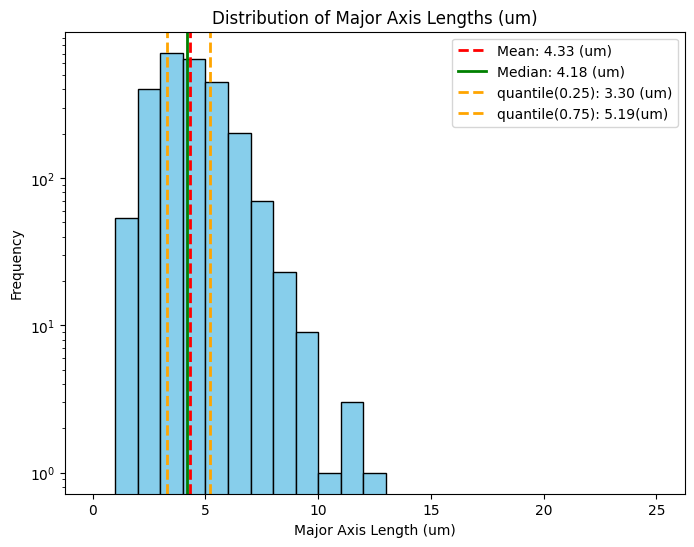

[DONE] Distribution analysis completed



{'track_density_per_cm2': 6375.180678315916,
 'mean': np.float64(4.3308404669260705),
 'std': np.float64(1.4326242412638588),
 'low': 3.3,
 'median': 4.18,
 'high': 5.19}

In [6]:
track_detector.inference_from_file( "Data/inference_results/segmentation/ARCI URAS26F2_Best_model_MAnet_efficientnet7_reducelr_dice_dice_bce_th0.1.csv" )
track_detector.get_track_distributions('seg')